# B_scale 对 CD_BOmega / CD_A 收敛速度与 SHD 的影响

测试不同 `B_scale` (0.1, 0.5, 1.0, 2.0, 5.0) 下两种算法的表现。

In [2]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset
from coordinate_descent.cd_greedy_A import dag_greedy_A_epoch
from coordinate_descent.cd_B_Omega import dag_coordinate_descent_BOmega_epoch as cd_BOmega

In [3]:
def weight_to_binary_adj(W, threshold=0.05):
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G

def shd_score(G_true, G_est):
    return int(np.sum(np.abs(G_true - G_est)))

def cpdag_shd_score(G_true, G_est):
    skel_true = get_skeleton(G_true)
    skel_est = get_skeleton(G_est)
    skeleton_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_true = find_v_structures(G_true)
    v_est = find_v_structures(G_est)
    v_diff = len(v_true.symmetric_difference(v_est))
    return float(skeleton_diff + v_diff)

def precision_recall_f1(G_true, G_est):
    true_edge = (G_true == 1)
    pred_edge = (G_est == 1)
    tp = int(np.sum(true_edge & pred_edge))
    fp = int(np.sum((~true_edge) & pred_edge))
    fn = int(np.sum(true_edge & (~pred_edge)))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

In [4]:
CFG = {
    'trials': 5,
    'seed': 42,
    'd': 30,
    'n': 20000,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'B_scale_list': [0.1, 0.5, 1.0, 2.0, 5.0],
    'threshold': 0.05,
    'lambda_l0': 0.1,
    'n_epochs': 500,
    'tol': 1e-4,
    'patience': 100,
    'min_epochs': 100,
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag': 'B_scale_convergence',
}
os.makedirs(CFG['out_dir'], exist_ok=True)
print('Config ready.')

Config ready.


In [5]:
rows = []
histories = {}  # (B_scale, algorithm) -> list of history arrays

rng = np.random.default_rng(CFG['seed'])
d, n = CFG['d'], CFG['n']
seeds = rng.integers(0, 10**9, size=CFG['trials'])

for bs in CFG['B_scale_list']:
    histories[(bs, 'CD_A')] = []
    histories[(bs, 'CD_BOmega')] = []
    
    for trial_idx, seed in enumerate(seeds, start=1):
        seed = int(seed)
        dataset = SyntheticDataset(
            n=n, d=d, graph_type='ER', degree=CFG['degree'],
            noise_type=CFG['noise_type'], B_scale=bs, seed=seed,
        )
        X = dataset.X
        S = X.T @ X / n
        G_true = weight_to_binary_adj(dataset.B, threshold=0.0)

        # --- CD_A ---
        t0 = time.perf_counter()
        A_est, G_A, obj_A, hist_A = dag_greedy_A_epoch(
            S=S, n_epochs=CFG['n_epochs'], seed=seed,
            threshold=CFG['threshold'], lambda_l0=CFG['lambda_l0'],
            tol=CFG['tol'], patience=CFG['patience'],
            min_epochs=CFG['min_epochs'], verbose=False,
        )
        rt_A = time.perf_counter() - t0
        histories[(bs, 'CD_A')].append(hist_A)

        p, r, f1 = precision_recall_f1(G_true, G_A)
        rows.append({
            'B_scale': bs, 'trial': trial_idx, 'seed': seed,
            'algorithm': 'CD_A', 'shd': shd_score(G_true, G_A),
            'cpdag_shd': cpdag_shd_score(G_true, G_A),
            'mec_match': int(is_in_markov_equiv_class(G_true, G_A)),
            'precision': p, 'recall': r, 'f1': f1,
            'n_edges_true': int(G_true.sum()), 'n_edges_est': int(G_A.sum()),
            'n_epochs_run': len(hist_A), 'runtime_sec': rt_A,
        })

        # --- CD_BOmega ---
        Omega0 = np.eye(d)
        t0 = time.perf_counter()
        B_est, G_BO, obj_BO, hist_BO, _ = cd_BOmega(
            S=S, Omega=Omega0, n_epochs=CFG['n_epochs'], seed=seed,
            threshold=CFG['threshold'], lambda_l0=0.0,
            tol=CFG['tol'], patience=CFG['patience'],
            min_epochs=CFG['min_epochs'], verbose=False,
        )
        rt_BO = time.perf_counter() - t0
        histories[(bs, 'CD_BOmega')].append(hist_BO)

        p, r, f1 = precision_recall_f1(G_true, G_BO)
        rows.append({
            'B_scale': bs, 'trial': trial_idx, 'seed': seed,
            'algorithm': 'CD_BOmega', 'shd': shd_score(G_true, G_BO),
            'cpdag_shd': cpdag_shd_score(G_true, G_BO),
            'mec_match': int(is_in_markov_equiv_class(G_true, G_BO)),
            'precision': p, 'recall': r, 'f1': f1,
            'n_edges_true': int(G_true.sum()), 'n_edges_est': int(G_BO.sum()),
            'n_epochs_run': len(hist_BO), 'runtime_sec': rt_BO,
        })

        print(f'B_scale={bs}  trial {trial_idx}/{CFG["trials"]}  '
              f'CD_A shd={rows[-2]["shd"]}  CD_BOmega shd={rows[-1]["shd"]}')

df = pd.DataFrame(rows)
print(f'\nDone. {len(df)} rows collected.')

B_scale=0.1  trial 1/5  CD_A shd=27  CD_BOmega shd=17
B_scale=0.1  trial 2/5  CD_A shd=31  CD_BOmega shd=37
B_scale=0.1  trial 3/5  CD_A shd=31  CD_BOmega shd=25
B_scale=0.1  trial 4/5  CD_A shd=33  CD_BOmega shd=45
B_scale=0.1  trial 5/5  CD_A shd=24  CD_BOmega shd=23
B_scale=0.5  trial 1/5  CD_A shd=22  CD_BOmega shd=22
B_scale=0.5  trial 2/5  CD_A shd=7  CD_BOmega shd=36
B_scale=0.5  trial 3/5  CD_A shd=22  CD_BOmega shd=19
B_scale=0.5  trial 4/5  CD_A shd=16  CD_BOmega shd=56
B_scale=0.5  trial 5/5  CD_A shd=11  CD_BOmega shd=5
B_scale=1.0  trial 1/5  CD_A shd=32  CD_BOmega shd=22
B_scale=1.0  trial 2/5  CD_A shd=41  CD_BOmega shd=23
B_scale=1.0  trial 3/5  CD_A shd=41  CD_BOmega shd=32
B_scale=1.0  trial 4/5  CD_A shd=44  CD_BOmega shd=21
B_scale=1.0  trial 5/5  CD_A shd=15  CD_BOmega shd=14
B_scale=2.0  trial 1/5  CD_A shd=49  CD_BOmega shd=12
B_scale=2.0  trial 2/5  CD_A shd=34  CD_BOmega shd=41
B_scale=2.0  trial 3/5  CD_A shd=52  CD_BOmega shd=64
B_scale=2.0  trial 4/5  CD_A s

## 汇总统计

In [6]:
summary = df.groupby(['B_scale', 'algorithm']).agg(
    shd_mean=('shd', 'mean'),
    shd_std=('shd', 'std'),
    cpdag_shd_mean=('cpdag_shd', 'mean'),
    mec_rate=('mec_match', 'mean'),
    f1_mean=('f1', 'mean'),
    epochs_mean=('n_epochs_run', 'mean'),
    runtime_mean=('runtime_sec', 'mean'),
).reset_index()

display(summary)

# 保存结果
df.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv"), index=False)
summary.to_csv(os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv"), index=False)
print('Results saved.')

,B_scale,algorithm,shd_mean,shd_std,cpdag_shd_mean,mec_rate,f1_mean,epochs_mean,runtime_mean
0,0.1,CD_A,29.2,3.633180,47.2,0.0,0.000000,199.0,6.012539
1,0.1,CD_BOmega,29.4,11.349009,22.0,0.0,0.516833,199.0,74.778212
2,0.5,CD_A,15.6,6.655825,17.4,0.0,0.708101,199.0,7.560268
3,0.5,CD_BOmega,27.6,19.320973,41.2,0.0,0.659272,199.0,69.174690
4,1.0,CD_A,34.6,11.844830,57.8,0.0,0.504229,199.0,9.315293
5,1.0,CD_BOmega,22.4,6.426508,44.0,0.0,0.689065,199.0,73.816423
6,2.0,CD_A,42.8,13.845577,71.2,0.0,0.414526,308.8,17.067231
7,2.0,CD_BOmega,46.6,34.202339,197.4,0.0,0.575403,351.0,141.289633
8,5.0,CD_A,47.6,17.558474,114.0,0.0,0.385536,436.4,25.180027
9,5.0,CD_BOmega,88.8,30.523761,632.8,0.0,0.384995,500.0,193.757284


Results saved.


## SHD vs B_scale

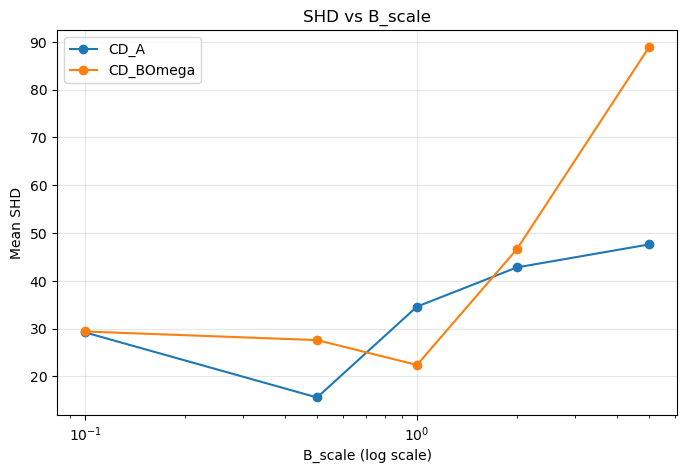

In [13]:
# plt SHD vs B_scale
df_plot = summary.copy()
fig, axes = plt.subplots(1, 1, figsize=(8, 5)) # 1 row, 1 column
# --- SHD ---
ax = axes
for alg in ['CD_A', 'CD_BOmega']:
    sub = df_plot[df_plot['algorithm'] == alg]
    ax.plot(sub['B_scale'], sub['shd_mean'], marker='o', label=alg)
ax.set_xscale('log')
ax.set_xlabel('B_scale (log scale)')
ax.set_ylabel('Mean SHD')
ax.set_title('SHD vs B_scale')
ax.legend()
ax.grid(True, alpha=0.3)    

## 收敛曲线（各 B_scale 下目标函数随 epoch 的变化）

C:\Users\super\AppData\Local\Temp\ipykernel_91176\1639207817.py:22: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_91176\1639207817.py:22: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_91176\1639207817.py:22: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_91176\1639207817.py:22: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\super\AppData\Local\Temp\ipykernel_91176\1639207817.py:23: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_convergence.png"), dpi=150)
C:\Users\super\AppData\Local\T

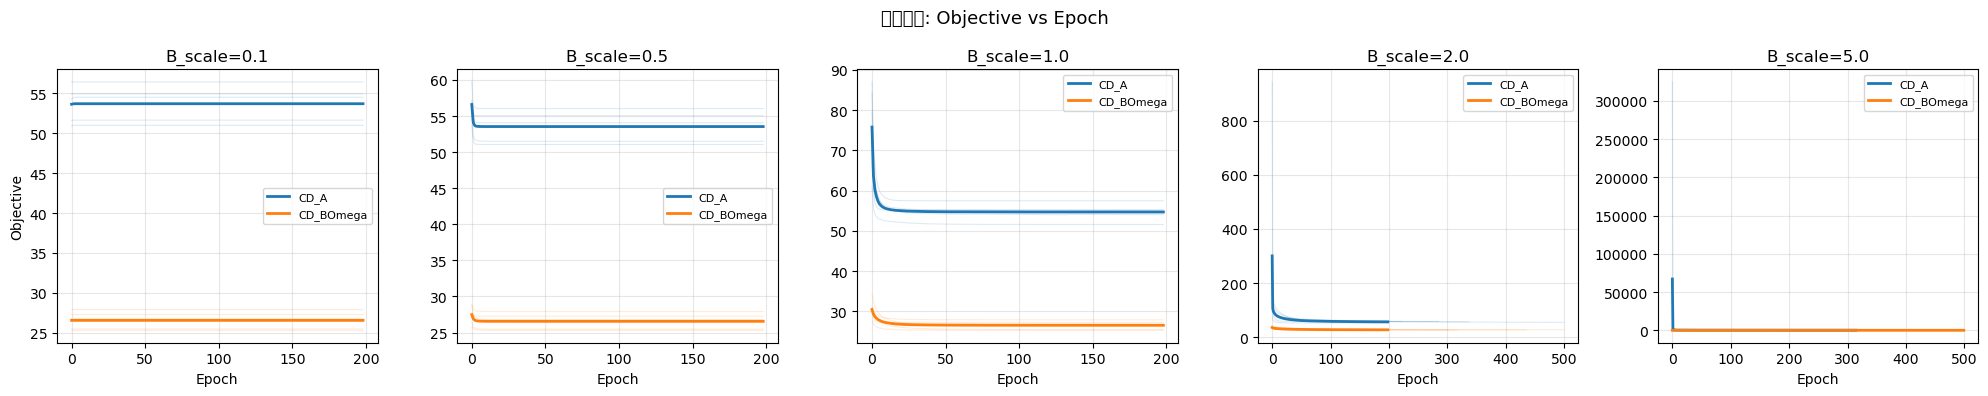

In [8]:
fig, axes = plt.subplots(1, len(CFG['B_scale_list']), figsize=(4 * len(CFG['B_scale_list']), 4), sharey=False)

for idx, bs in enumerate(CFG['B_scale_list']):
    ax = axes[idx]
    for alg, color in [('CD_A', 'tab:blue'), ('CD_BOmega', 'tab:orange')]:
        hists = histories[(bs, alg)]
        # 绘制每条 trial 的淡色线
        for h in hists:
            ax.plot(range(len(h)), h, color=color, alpha=0.15, linewidth=0.8)
        # 绘制 trial 均值（对齐到最短长度）
        min_len = min(len(h) for h in hists)
        arr = np.array([h[:min_len] for h in hists])
        ax.plot(range(min_len), arr.mean(axis=0), color=color, linewidth=2, label=alg)
    ax.set_title(f'B_scale={bs}')
    ax.set_xlabel('Epoch')
    if idx == 0:
        ax.set_ylabel('Objective')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('收敛曲线: Objective vs Epoch', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], f"{CFG['tag']}_convergence.png"), dpi=150)
plt.show()

## 收敛 epoch 数 vs B_scale